# Analizaremos los CSV creados en SQL que eran los incidentes y el de todos los datos unidos

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import Funciones as f
from scipy.stats import spearmanr
import plotly.express as px


In [80]:
df = pd.read_csv("incidentes.csv")

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 64 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_evento                    328 non-null    object 
 1   ciudad                       328 non-null    object 
 2   estado                       328 non-null    object 
 3   tipo_evento                  328 non-null    object 
 4   fecha_hora_programada        328 non-null    object 
 5   fecha_hora_real              328 non-null    object 
 6   minutos_de_detencion         328 non-null    int64  
 7   tem_max_C                    328 non-null    int64  
 8   tem_min_C                    328 non-null    int64  
 9   tem_C                        328 non-null    int64  
 10  rocio_C                      328 non-null    int64  
 11  humedad_pct                  328 non-null    int64  
 12  precip_mm                    328 non-null    int64  
 13  prob_precip_pct     

In [82]:
df.head()

,id_evento,ciudad,estado,tipo_evento,fecha_hora_programada,fecha_hora_real,minutos_de_detencion,tem_max_C,tem_min_C,tem_C,...,costo_total_eur,fecha_incidente,tipo_incidente,ciudad_incidente,indicador_de_falla,indicador_de_lesion,monto_reclamacion_eur,indicador_prevenible,nivel,causa
0,EVT00064924,Los Angeles,CA,Entrega,2023-02-21 06:32:44,2023-02-21 11:57:51,124,17,9,13,...,247.0,2023-02-19,Infracción de tránsito,Columbus,0,0,14452,0,Grave,Clima
1,EVT00064924,Los Angeles,CA,Entrega,2023-02-21 06:32:44,2023-02-21 11:57:51,124,17,9,13,...,324.0,2023-02-19,Infracción de tránsito,Columbus,0,0,14452,0,Grave,Clima
2,EVT00135166,New York,NY,Entrega,2024-05-18 22:28:35,2024-05-19 00:02:55,28,23,14,18,...,435.0,2024-05-20,Queja del cliente,Seattle,1,0,20678,1,Leve,Tráfico
3,EVT00135166,New York,NY,Entrega,2024-05-18 22:28:35,2024-05-19 00:02:55,28,23,14,18,...,369.0,2024-05-20,Queja del cliente,Seattle,1,0,20678,1,Leve,Tráfico
4,EVT00135166,New York,NY,Entrega,2024-05-18 22:28:35,2024-05-19 00:02:55,28,23,14,18,...,295.0,2024-05-20,Queja del cliente,Seattle,1,0,20678,1,Leve,Tráfico


## Veamos el total de incidentes por estado:

In [83]:
df_inc = df.groupby('estado')['id_evento'].nunique().reset_index()
df_inc.columns = ['estado', 'conteo']

In [84]:
df_inc

,estado,conteo
0,CA,18
1,FL,13
2,MI,9
3,MO,32
4,NY,14
5,OR,31
6,TX,25


In [85]:
fig = px.choropleth(df_inc, 
                    locations='estado', 
                    locationmode="USA-states", 
                    color='conteo',
                    scope="usa",
                    title='Incidentes por Estado',
                    color_continuous_scale="Viridis")
fig.show()

La mayor parte de los incidentes ocurren en Kansas City con 32 y en Portland con 31. Mientras que la menor cantidad de incidentes ocurren en Detroit con 9.

## Veamos ahora la distribución de los incidentes por causa, tipo y si son de entrega o recogida

In [86]:
grouped = df.groupby([ "tipo_incidente","tipo_evento","causa"])["id_evento"].nunique().reset_index(name='conteo').sort_values(by='conteo', ascending=False)

In [87]:
grouped

,tipo_incidente,tipo_evento,causa,conteo
9,Daño de equipo,Entrega,Equipo,10
17,Fallo mecánico o exceso horas permitidas,Entrega,Otro conductor,9
3,Accidente,Entrega,Tráfico,7
0,Accidente,Entrega,Clima,6
16,Fallo mecánico o exceso horas permitidas,Entrega,Equipo,6
26,Infracción de tránsito,Entrega,Tráfico,6
30,Queja del cliente,Entrega,Clima,5
2,Accidente,Entrega,Otro conductor,5
35,Queja del cliente,Recogida,Equipo,5
18,Fallo mecánico o exceso horas permitidas,Entrega,Tráfico,5


In [88]:
total_recogida = grouped[grouped['tipo_evento'] == 'Recogida']["conteo"].sum()
total_entrega = grouped[grouped['tipo_evento'] == 'Entrega']["conteo"].sum()
print(f"Total de incidentes por Recogida: {total_recogida}")
print(f"Total de incidentes por Entrega: {total_entrega}") 

Total de incidentes por Recogida: 54
Total de incidentes por Entrega: 88


In [89]:
total_clima = grouped[grouped["causa"] == "Clima"]["conteo"].sum()
print(f"Total de incidentes por clima: {total_clima}")


Total de incidentes por clima: 32


In [90]:
grouped2 = df[df["causa"] == "Clima"].groupby(["tipo_evento", "tipo_incidente"])["id_evento"].nunique().reset_index(name='conteo').sort_values(by='conteo', ascending=False)


In [91]:
grouped2

,tipo_evento,tipo_incidente,conteo
0,Entrega,Accidente,6
4,Entrega,Queja del cliente,5
5,Recogida,Accidente,4
7,Recogida,Fallo mecánico o exceso horas permitidas,4
1,Entrega,Daño de equipo,3
3,Entrega,Infracción de tránsito,3
2,Entrega,Fallo mecánico o exceso horas permitidas,3
6,Recogida,Daño de equipo,2
8,Recogida,Queja del cliente,2


Con esta información podemos ver que hay más incidentes de entrega que de recogida. Además tenemos que de los 142 incidentes totales, 32 son por causados por el clima en Entrega hay 20 y en Recogida hay 12.

veamos por tráfico 

In [92]:
grouped3 = df[df["causa"] == "Tráfico"].groupby(["tipo_evento", "tipo_incidente"])["id_evento"].nunique().reset_index(name='conteo').sort_values(by='conteo', ascending=False)

In [93]:
grouped3

,tipo_evento,tipo_incidente,conteo
0,Entrega,Accidente,7
2,Entrega,Infracción de tránsito,6
1,Entrega,Fallo mecánico o exceso horas permitidas,5
6,Recogida,Fallo mecánico o exceso horas permitidas,5
3,Entrega,Queja del cliente,4
8,Recogida,Queja del cliente,4
4,Recogida,Accidente,3
5,Recogida,Daño de equipo,2
7,Recogida,Infracción de tránsito,2


Incidentes son 38

In [94]:
grouped4 = df[df["causa"] == "Equipo"].groupby(["tipo_evento", "tipo_incidente"])["id_evento"].nunique().reset_index(name='conteo').sort_values(by='conteo', ascending=False)

In [95]:
grouped4

,tipo_evento,tipo_incidente,conteo
1,Entrega,Daño de equipo,10
2,Entrega,Fallo mecánico o exceso horas permitidas,6
9,Recogida,Queja del cliente,5
6,Recogida,Daño de equipo,4
3,Entrega,Infracción de tránsito,3
0,Entrega,Accidente,2
5,Recogida,Accidente,2
4,Entrega,Queja del cliente,2
8,Recogida,Infracción de tránsito,2
7,Recogida,Fallo mecánico o exceso horas permitidas,1


38 en total

In [96]:
grouped5 = df[df["causa"] == "Otro conductor"].groupby(["tipo_evento", "tipo_incidente"])["id_evento"].nunique().reset_index(name='conteo').sort_values(by='conteo', ascending=False)

In [97]:
grouped5

,tipo_evento,tipo_incidente,conteo
2,Entrega,Fallo mecánico o exceso horas permitidas,9
0,Entrega,Accidente,5
1,Entrega,Daño de equipo,5
6,Recogida,Daño de equipo,4
5,Recogida,Accidente,3
7,Recogida,Fallo mecánico o exceso horas permitidas,3
3,Entrega,Infracción de tránsito,2
4,Entrega,Queja del cliente,2
8,Recogida,Infracción de tránsito,2


35 en total

## Analizamos los casos que fueron a repostar combustible

In [98]:
bencina= df.groupby(["id_evento","ciudad","ciudad_origen","ciudad_destino","causa"])["fecha_compra"].count().sort_values(ascending=False)

In [99]:
bencina

id_evento    ciudad       ciudad_origen  ciudad_destino  causa         
EVT00150023  Kansas City  Kansas City    Miami           Tráfico           6
EVT00146462  Miami        Atlanta        Miami           Otro conductor    6
EVT00158576  Los Angeles  Chicago        Los Angeles     Otro conductor    6
EVT00150024  Miami        Kansas City    Miami           Tráfico           6
EVT00079712  Kansas City  Denver         Kansas City     Clima             6
                                                                          ..
EVT00026854  Portland     Columbus       Portland        Equipo            0
EVT00040006  New York     Las Vegas      New York        Tráfico           0
EVT00137011  Houston      Houston        Memphis         Equipo            0
EVT00162248  Houston      Minneapolis    Houston         Otro conductor    0
EVT00162926  Houston      Seattle        Houston         Clima             0
Name: fecha_compra, Length: 142, dtype: int64

In [100]:
tabla_frecuencia = (
    bencina.value_counts()
    .sort_index()
    .reindex(range(7), fill_value=0)
    .reset_index()
)

tabla_frecuencia.columns = ['Veces Repostado (Bencina)', 'Cantidad de Eventos']

tabla_frecuencia

,Veces Repostado (Bencina),Cantidad de Eventos
0,0,13
1,1,36
2,2,42
3,3,27
4,4,11
5,5,8
6,6,5


Observamos que de los 142 incidentes totales, 36 repostan bencina 1 sola vez.

## Analizamos ahora el tiempo de retraso

Haremos una columna para ver cuanto tiempo hay de retraso.

In [101]:
df['fecha_hora_programada'] = pd.to_datetime(df['fecha_hora_programada'])
df['fecha_hora_real'] = pd.to_datetime(df['fecha_hora_real'])


In [102]:
diferencia = df['fecha_hora_real'] - df['fecha_hora_programada']

df.insert(df.columns.get_loc('fecha_hora_real') + 1, 'retraso_minutos', (diferencia.dt.total_seconds() / 60).round(2))


In [103]:
df.head()

,id_evento,ciudad,estado,tipo_evento,fecha_hora_programada,fecha_hora_real,retraso_minutos,minutos_de_detencion,tem_max_C,tem_min_C,...,costo_total_eur,fecha_incidente,tipo_incidente,ciudad_incidente,indicador_de_falla,indicador_de_lesion,monto_reclamacion_eur,indicador_prevenible,nivel,causa
0,EVT00064924,Los Angeles,CA,Entrega,2023-02-21 06:32:44,2023-02-21 11:57:51,325.12,124,17,9,...,247.0,2023-02-19,Infracción de tránsito,Columbus,0,0,14452,0,Grave,Clima
1,EVT00064924,Los Angeles,CA,Entrega,2023-02-21 06:32:44,2023-02-21 11:57:51,325.12,124,17,9,...,324.0,2023-02-19,Infracción de tránsito,Columbus,0,0,14452,0,Grave,Clima
2,EVT00135166,New York,NY,Entrega,2024-05-18 22:28:35,2024-05-19 00:02:55,94.33,28,23,14,...,435.0,2024-05-20,Queja del cliente,Seattle,1,0,20678,1,Leve,Tráfico
3,EVT00135166,New York,NY,Entrega,2024-05-18 22:28:35,2024-05-19 00:02:55,94.33,28,23,14,...,369.0,2024-05-20,Queja del cliente,Seattle,1,0,20678,1,Leve,Tráfico
4,EVT00135166,New York,NY,Entrega,2024-05-18 22:28:35,2024-05-19 00:02:55,94.33,28,23,14,...,295.0,2024-05-20,Queja del cliente,Seattle,1,0,20678,1,Leve,Tráfico


Veamos los 142 incidentes y sus tiempos de retraso:

In [104]:
df_eventos = df.drop_duplicates(subset=['id_evento'])

In [105]:
f.categorico(df_eventos,"retraso_minutos")

retraso_minutos
 325.12    1
 94.33     1
-153.58    1
-92.38     1
-92.05     1
          ..
 33.83     1
 341.80    1
 93.95     1
-160.93    1
-115.33    1
Name: count, Length: 142, dtype: int64
[ 3.2512e+02  9.4330e+01 -1.5358e+02 -9.2380e+01 -9.2050e+01 -5.0800e+01
  2.3402e+02  7.2270e+01 -4.5770e+01  1.7697e+02  3.0422e+02  3.3318e+02
 -8.0700e+00  3.0130e+01  2.0670e+02  1.7065e+02  2.4720e+02  3.2628e+02
  1.2105e+02  9.0280e+01 -1.0707e+02  1.9937e+02  3.3495e+02  2.9278e+02
  3.1230e+01 -8.8620e+01  2.1102e+02  1.1620e+01  3.3073e+02 -2.4070e+01
  1.6495e+02  1.3030e+01  2.2193e+02  1.8993e+02  3.5120e+01 -1.6165e+02
 -6.0650e+01  1.9550e+02 -5.3820e+01  1.8618e+02  1.7343e+02 -3.6280e+01
  5.9280e+01  1.4390e+02  8.7880e+01  1.6452e+02  1.8083e+02  4.4180e+01
 -4.2720e+01  2.1333e+02  8.7470e+01 -1.5017e+02  2.3508e+02  1.7432e+02
  3.1718e+02 -5.3550e+01  2.8932e+02  1.9568e+02 -1.0080e+02  9.4730e+01
  1.6092e+02  2.7978e+02 -1.2608e+02  1.0295e+02  3.5463e+02  1.7000e-01

Veamos como se comporta la variable del retraso del tiempo

In [106]:
f.numerico(df_eventos, "retraso_minutos")

count    142.000000
mean      96.456901
std      137.189152
min     -161.650000
25%       -7.345000
50%       94.140000
75%      198.447500
max      354.630000
Name: retraso_minutos, dtype: float64
0
142


El evento que se demora más lo hace en 354,63 minutos que son aproximadamente 5,9 horas.

Veamos un diagrama de cajas para ver la distribución de los retrasos:

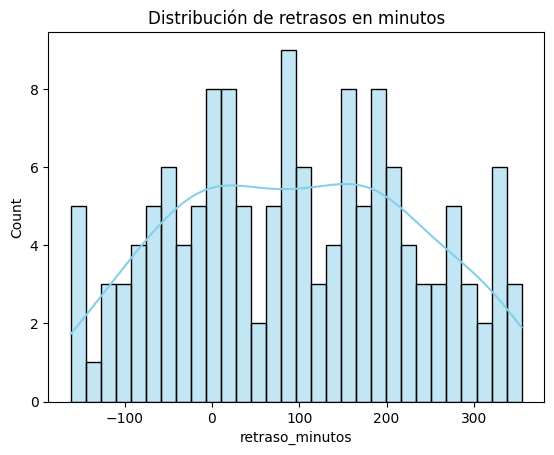

In [107]:
sns.histplot(df_eventos['retraso_minutos'], kde=True, bins=30, color="skyblue")
plt.title('Distribución de retrasos en minutos')
plt.show()

Text(0.5, 1.0, 'Distribución de retrasos')

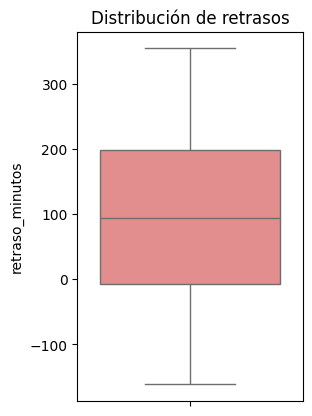

In [108]:
plt.subplot(1, 2, 2)
sns.boxplot(y=df_eventos['retraso_minutos'], color='lightcoral')
plt.title('Distribución de retrasos')

In [109]:
df_eventos['a_tiempo'] = df_eventos['fecha_hora_real'] <= df_eventos['fecha_hora_programada']

porcentaje_otd = df_eventos['a_tiempo'].mean() * 100

print(f"El porcentaje de eventos a tiempo es: {porcentaje_otd:.2f}%")
print(f"El porcentaje de eventos tarde es: {100 - porcentaje_otd:.2f}%")

El porcentaje de eventos a tiempo es: 28.17%
El porcentaje de eventos tarde es: 71.83%


C:\Users\tachi\AppData\Local\Temp\ipykernel_33764\513591887.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Observando todos estos datos  y gráficos podemos ver que nuestros incidentes tienen un 28,17% de cumplimiento respecto a la entrega o recogida.

# Analizamos los viajes totales incluidos los incidentes.

In [110]:
df_union = pd.read_csv("UNION.csv")
df_union.head()

,id_evento,ciudad,tipo_evento,fecha_hora_programada,fecha_hora_real,minutos_de_detencion,tem_max_C,tem_min_C,tem_C,rocio_C,...,galones_combustible_usados,mpg_promedio,horas_de_ralenti_RPM,fecha_carga,tipo_carga,peso_kg,eur_carga,recargo_combustible,cargos_accesorios,tipo_reserva
0,EVT00000001,Houston,Recogida,2022-01-01 18:00:00,2022-01-01 20:58:55,0,27,23,25,69,...,184,7,4,2022-01-01 00:00:00,Seco,8699,2591,407,100,Puntual
1,EVT00000002,Detroit,Entrega,2022-01-02 23:10:56,2022-01-02 21:30:22,230,-3,-8,-4,17,...,184,7,4,2022-01-01 00:00:00,Seco,8699,2591,407,100,Puntual
2,EVT00000003,Kansas City,Recogida,2022-01-01 18:00:00,2022-01-01 17:37:26,62,1,-12,-8,13,...,94,6,8,2022-01-01 00:00:00,Seco,12592,1042,99,0,Dedicado
3,EVT00000006,Portland,Entrega,2022-01-03 04:28:02,2022-01-03 03:05:02,11,9,3,5,37,...,339,7,12,2022-01-01 00:00:00,Refrigerado,16145,6102,793,0,Puntual
4,EVT00000009,Houston,Recogida,2022-01-01 08:00:00,2022-01-01 11:51:35,73,27,23,25,69,...,329,7,12,2022-01-01 00:00:00,Seco,18260,2822,738,0,Puntual


In [111]:
f.categorico(df_union,"ciudad_destino")

ciudad_destino
Los Angeles     10420
Portland        10282
Houston          5929
Kansas City      5889
Detroit          5830
New York         4516
Seattle          4426
Miami            4367
Columbus         2973
Philadelphia     2965
Charlotte        1469
Denver           1440
Indianapolis     1432
Memphis          1424
Dallas           1398
Atlanta          1386
Name: count, dtype: int64
['Detroit' 'Indianapolis' 'Portland' 'Seattle' 'Kansas City' 'Miami'
 'New York' 'Los Angeles' 'Columbus' 'Memphis' 'Denver' 'Philadelphia'
 'Atlanta' 'Houston' 'Dallas' 'Charlotte']
16


In [112]:
f.categorico(df_union, "id_evento")

id_evento
EVT00000001    1
EVT00000002    1
EVT00000003    1
EVT00000006    1
EVT00000009    1
              ..
EVT00170808    1
EVT00170810    1
EVT00170815    1
EVT00170816    1
EVT00170820    1
Name: count, Length: 66146, dtype: int64
['EVT00000001' 'EVT00000002' 'EVT00000003' ... 'EVT00170815' 'EVT00170816'
 'EVT00170820']
66146


In [113]:
df_union["id_evento"].nunique()

66146

In [114]:
df_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66146 entries, 0 to 66145
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_evento                    66146 non-null  object 
 1   ciudad                       66146 non-null  object 
 2   tipo_evento                  66146 non-null  object 
 3   fecha_hora_programada        66146 non-null  object 
 4   fecha_hora_real              66146 non-null  object 
 5   minutos_de_detencion         66146 non-null  int64  
 6   tem_max_C                    66146 non-null  int64  
 7   tem_min_C                    66146 non-null  int64  
 8   tem_C                        66146 non-null  int64  
 9   rocio_C                      66146 non-null  int64  
 10  humedad_pct                  66146 non-null  int64  
 11  precip_mm                    66146 non-null  int64  
 12  tipo_precip                  66146 non-null  object 
 13  nieve_mm        

In [115]:
df_union.columns

Index(['id_evento', 'ciudad', 'tipo_evento', 'fecha_hora_programada',
       'fecha_hora_real', 'minutos_de_detencion', 'tem_max_C', 'tem_min_C',
       'tem_C', 'rocio_C', 'humedad_pct', 'precip_mm', 'tipo_precip',
       'nieve_mm', 'prof_nieve_mm', 'dir_viento_gr', 'nubosidad_pct',
       'visibilidad_km', 'riesgo_severo', 'condiciones', 'ciudad_origen',
       'ciudad_destino', 'distancia_tipica_millas', 'distancia_km',
       'tarifa_base_milla_eur', 'tasa_de_recargo_combustible',
       'dias_de_transito_tipicos', 'nombre_cliente', 'tipo_cliente',
       'tipo_carga_principal', 'ingreso_eur', 'fecha_despacho',
       'distancia_viaje', 'duracion_real_horas', 'galones_combustible_usados',
       'mpg_promedio', 'horas_de_ralenti_RPM', 'fecha_carga', 'tipo_carga',
       'peso_kg', 'eur_carga', 'recargo_combustible', 'cargos_accesorios',
       'tipo_reserva'],
      dtype='object')

In [116]:
f.categorico(df_union,"tipo_precip")

tipo_precip
Nada         42460
lluvia       21854
rain,snow     1342
nieve          490
Name: count, dtype: int64
['Nada' 'nieve' 'lluvia' 'rain,snow']
4


In [117]:
df_union = f.cambiar_filas(df_union, "tipo_precip", 'rain,snow',"lluvia, nieve")

Veamos cuanto es el retraso según la hora de programación versus la hora real

In [118]:
df_union['fecha_hora_programada'] = pd.to_datetime(df_union['fecha_hora_programada'])
df_union['fecha_hora_real'] = pd.to_datetime(df_union['fecha_hora_real'])


In [119]:
diferencia = df_union['fecha_hora_real'] - df_union['fecha_hora_programada']

df_union.insert(df_union.columns.get_loc('fecha_hora_real') + 1, 'retraso_minutos', (diferencia.dt.total_seconds() / 60).round(2))

In [120]:
df_union.head()

,id_evento,ciudad,tipo_evento,fecha_hora_programada,fecha_hora_real,retraso_minutos,minutos_de_detencion,tem_max_C,tem_min_C,tem_C,...,galones_combustible_usados,mpg_promedio,horas_de_ralenti_RPM,fecha_carga,tipo_carga,peso_kg,eur_carga,recargo_combustible,cargos_accesorios,tipo_reserva
0,EVT00000001,Houston,Recogida,2022-01-01 18:00:00,2022-01-01 20:58:55,178.92,0,27,23,25,...,184,7,4,2022-01-01 00:00:00,Seco,8699,2591,407,100,Puntual
1,EVT00000002,Detroit,Entrega,2022-01-02 23:10:56,2022-01-02 21:30:22,-100.57,230,-3,-8,-4,...,184,7,4,2022-01-01 00:00:00,Seco,8699,2591,407,100,Puntual
2,EVT00000003,Kansas City,Recogida,2022-01-01 18:00:00,2022-01-01 17:37:26,-22.57,62,1,-12,-8,...,94,6,8,2022-01-01 00:00:00,Seco,12592,1042,99,0,Dedicado
3,EVT00000006,Portland,Entrega,2022-01-03 04:28:02,2022-01-03 03:05:02,-83.00,11,9,3,5,...,339,7,12,2022-01-01 00:00:00,Refrigerado,16145,6102,793,0,Puntual
4,EVT00000009,Houston,Recogida,2022-01-01 08:00:00,2022-01-01 11:51:35,231.58,73,27,23,25,...,329,7,12,2022-01-01 00:00:00,Seco,18260,2822,738,0,Puntual


Si los minutos de retraso son negativos, significa que la entrega o recepción se realizó antes de la hora programada.

In [121]:
df_union['a_tiempo'] = df_union['fecha_hora_real'] <= df_union['fecha_hora_programada']

porcentaje_otd = df_union['a_tiempo'].mean() * 100

print(f"El porcentaje de eventos a tiempo es: {porcentaje_otd:.2f}%")
print(f"El porcentaje de eventos tarde es: {100 - porcentaje_otd:.2f}%")


El porcentaje de eventos a tiempo es: 33.28%
El porcentaje de eventos tarde es: 66.72%


In [122]:
f.categorico(df_union, "a_tiempo")

a_tiempo
False    44131
True     22015
Name: count, dtype: int64
[False  True]
2


Veamos un gráfico de los eventos que llegaron a tiempo y los que no

In [123]:
df_conteos = df_union['a_tiempo'].value_counts().reset_index()

fig = px.pie(
    df_conteos, 
    values='count',      
    names='a_tiempo',   
    title='Distribución de Pedidos a Tiempo',
    hole=0.3
)

fig.update_traces(textinfo='percent+label')

fig.show()

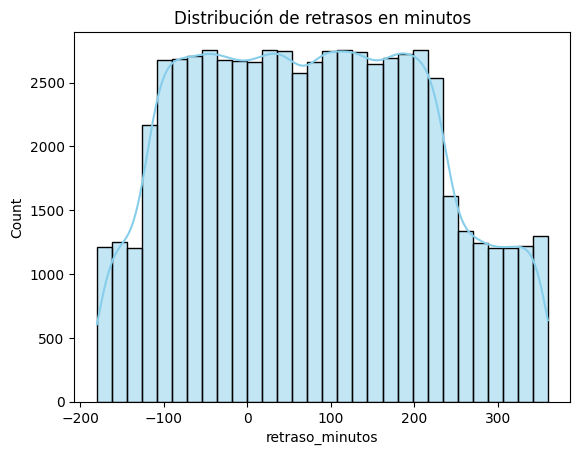

In [124]:
sns.histplot(df_union['retraso_minutos'], kde=True, bins=30, color="skyblue")
plt.title('Distribución de retrasos en minutos')
plt.show()

Text(0.5, 1.0, 'Distribución de retrasos')

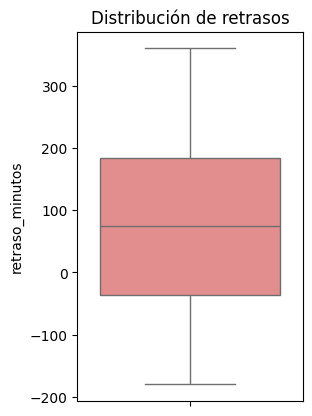

In [125]:
plt.subplot(1, 2, 2)
sns.boxplot(y=df_union['retraso_minutos'], color='lightcoral')
plt.title('Distribución de retrasos')

In [126]:
df_union.head()

,id_evento,ciudad,tipo_evento,fecha_hora_programada,fecha_hora_real,retraso_minutos,minutos_de_detencion,tem_max_C,tem_min_C,tem_C,...,mpg_promedio,horas_de_ralenti_RPM,fecha_carga,tipo_carga,peso_kg,eur_carga,recargo_combustible,cargos_accesorios,tipo_reserva,a_tiempo
0,EVT00000001,Houston,Recogida,2022-01-01 18:00:00,2022-01-01 20:58:55,178.92,0,27,23,25,...,7,4,2022-01-01 00:00:00,Seco,8699,2591,407,100,Puntual,False
1,EVT00000002,Detroit,Entrega,2022-01-02 23:10:56,2022-01-02 21:30:22,-100.57,230,-3,-8,-4,...,7,4,2022-01-01 00:00:00,Seco,8699,2591,407,100,Puntual,True
2,EVT00000003,Kansas City,Recogida,2022-01-01 18:00:00,2022-01-01 17:37:26,-22.57,62,1,-12,-8,...,6,8,2022-01-01 00:00:00,Seco,12592,1042,99,0,Dedicado,True
3,EVT00000006,Portland,Entrega,2022-01-03 04:28:02,2022-01-03 03:05:02,-83.00,11,9,3,5,...,7,12,2022-01-01 00:00:00,Refrigerado,16145,6102,793,0,Puntual,True
4,EVT00000009,Houston,Recogida,2022-01-01 08:00:00,2022-01-01 11:51:35,231.58,73,27,23,25,...,7,12,2022-01-01 00:00:00,Seco,18260,2822,738,0,Puntual,False


Agregaremos una columna para ver el riesgo de severidad.

In [127]:
df_union['categoria_riesgo'] = df_union['riesgo_severo'].apply(lambda x: 'Sin Riesgo' if x == 0 else ('Riesgo Moderado' if x <= 50 else 'Riesgo Alto'))

C:\Users\tachi\AppData\Local\Temp\ipykernel_33764\1007449853.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




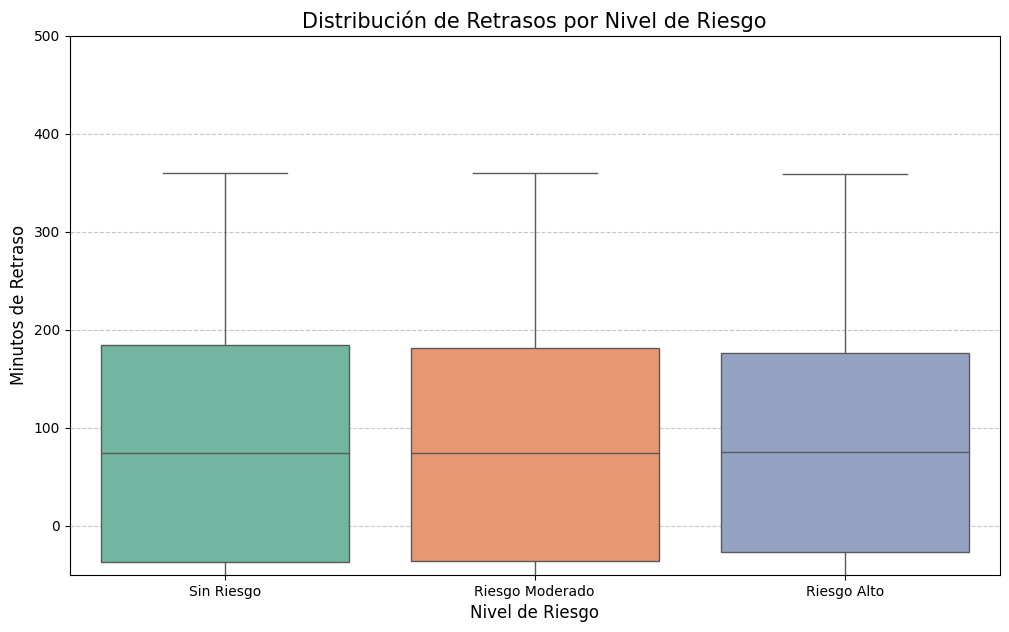

In [128]:
plt.figure(figsize=(12, 7))

sns.boxplot(x='categoria_riesgo', y='retraso_minutos', data=df_union, palette='Set2')

plt.title('Distribución de Retrasos por Nivel de Riesgo', fontsize=15)
plt.xlabel('Nivel de Riesgo', fontsize=12)
plt.ylabel('Minutos de Retraso', fontsize=12)
plt.ylim(-50, 500) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Observemos las variables numéricas y sus distribuciones

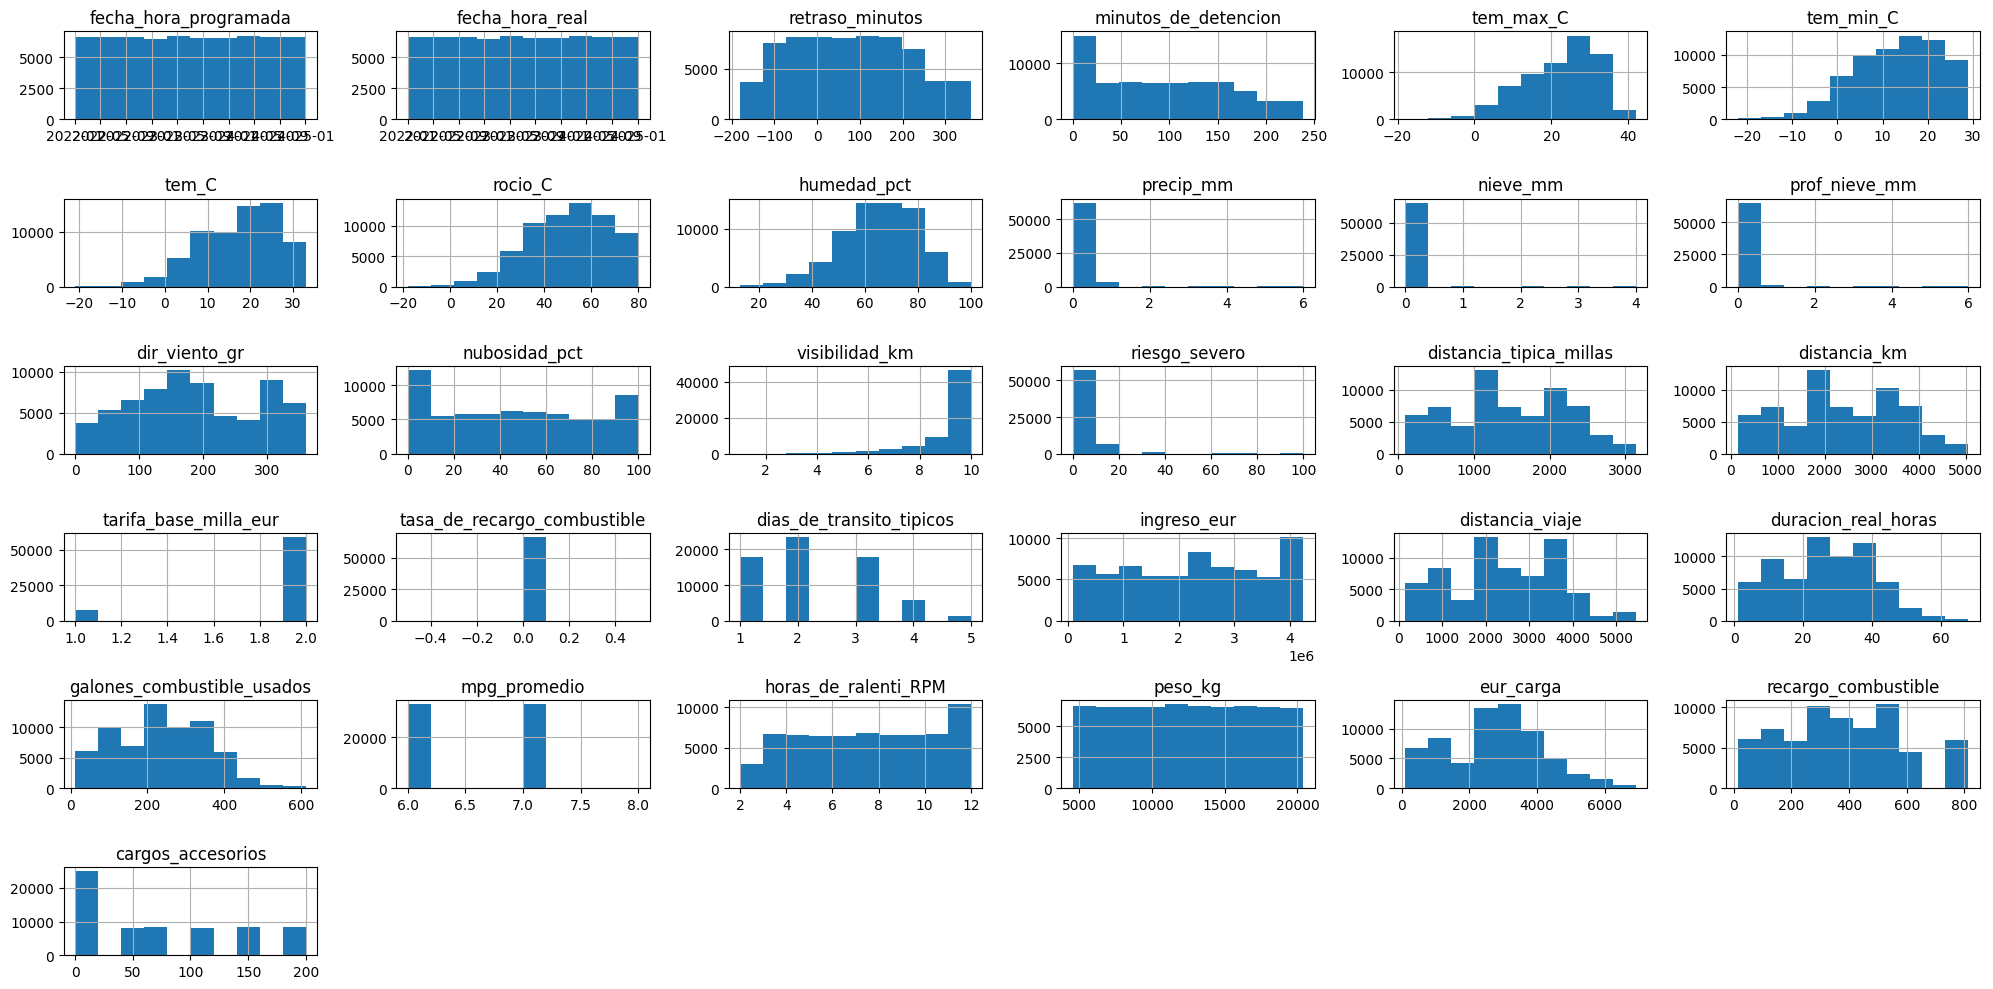

In [129]:
df_union.hist(figsize=(20,10))
plt.tight_layout()
plt.show()

veamos el dataframe de eventos 

In [130]:
df_union.columns    

Index(['id_evento', 'ciudad', 'tipo_evento', 'fecha_hora_programada',
       'fecha_hora_real', 'retraso_minutos', 'minutos_de_detencion',
       'tem_max_C', 'tem_min_C', 'tem_C', 'rocio_C', 'humedad_pct',
       'precip_mm', 'tipo_precip', 'nieve_mm', 'prof_nieve_mm',
       'dir_viento_gr', 'nubosidad_pct', 'visibilidad_km', 'riesgo_severo',
       'condiciones', 'ciudad_origen', 'ciudad_destino',
       'distancia_tipica_millas', 'distancia_km', 'tarifa_base_milla_eur',
       'tasa_de_recargo_combustible', 'dias_de_transito_tipicos',
       'nombre_cliente', 'tipo_cliente', 'tipo_carga_principal', 'ingreso_eur',
       'fecha_despacho', 'distancia_viaje', 'duracion_real_horas',
       'galones_combustible_usados', 'mpg_promedio', 'horas_de_ralenti_RPM',
       'fecha_carga', 'tipo_carga', 'peso_kg', 'eur_carga',
       'recargo_combustible', 'cargos_accesorios', 'tipo_reserva', 'a_tiempo',
       'categoria_riesgo'],
      dtype='object')

In [131]:
f.categorico(df_union, "condiciones")

condiciones
Parcialmente nublado                   23725
Despejado                              17597
Lluvia, parcialmente nublado           15271
Lluvia, nublado                         5995
Nublado                                 1689
Nieve, lluvia, nublado                   648
Lluvia                                   541
Nieve, lluvia, parcialmente nublado      488
Nieve, parcialmente nublado              113
Nieve, nublado                            64
Nieve                                     15
Name: count, dtype: int64
['Parcialmente nublado' 'Nieve, parcialmente nublado' 'Nieve, nublado'
 'Lluvia, nublado' 'Nieve, lluvia, nublado' 'Despejado'
 'Lluvia, parcialmente nublado' 'Nieve, lluvia, parcialmente nublado'
 'Nublado' 'Nieve' 'Lluvia']
11


In [132]:
df_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66146 entries, 0 to 66145
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id_evento                    66146 non-null  object        
 1   ciudad                       66146 non-null  object        
 2   tipo_evento                  66146 non-null  object        
 3   fecha_hora_programada        66146 non-null  datetime64[ns]
 4   fecha_hora_real              66146 non-null  datetime64[ns]
 5   retraso_minutos              66146 non-null  float64       
 6   minutos_de_detencion         66146 non-null  int64         
 7   tem_max_C                    66146 non-null  int64         
 8   tem_min_C                    66146 non-null  int64         
 9   tem_C                        66146 non-null  int64         
 10  rocio_C                      66146 non-null  int64         
 11  humedad_pct                  66146 non-nu

# Analizamos la relación entre las variables haciendo un heatmap con algunas variables

In [133]:
cols_interes = ['retraso_minutos', 'minutos_de_detencion','tem_max_C', 'tem_min_C', 'tem_C', 'rocio_C', 'humedad_pct',
    'precip_mm', 'nieve_mm', 'prof_nieve_mm', 'dir_viento_gr', 'nubosidad_pct', 'visibilidad_km', 'riesgo_severo',
    'distancia_km', 'tarifa_base_milla_eur',
    'dias_de_transito_tipicos','ingreso_eur', 'distancia_viaje', 'duracion_real_horas',
    'galones_combustible_usados', 'mpg_promedio', 'horas_de_ralenti_RPM','peso_kg']


In [134]:
df_corr = df_union[cols_interes].dropna()

matriz_corr = df_corr.corr(method='spearman')


In [135]:
matriz_corr

,retraso_minutos,minutos_de_detencion,tem_max_C,tem_min_C,tem_C,rocio_C,humedad_pct,precip_mm,nieve_mm,prof_nieve_mm,...,distancia_km,tarifa_base_milla_eur,dias_de_transito_tipicos,ingreso_eur,distancia_viaje,duracion_real_horas,galones_combustible_usados,mpg_promedio,horas_de_ralenti_RPM,peso_kg
retraso_minutos,1.000000,0.025696,-0.009795,-0.009721,-0.010046,-0.009060,-0.000142,0.002860,0.001832,0.000449,...,0.017530,0.018711,0.017414,-0.002327,0.016807,0.016536,0.015329,0.003146,-0.001666,-0.001381
minutos_de_detencion,0.025696,1.000000,-0.015835,-0.018219,-0.019032,-0.021808,-0.010413,-0.006266,0.001705,0.007930,...,0.028197,0.047970,0.030125,0.002502,0.027433,0.027430,0.026515,0.003611,-0.009316,0.002301
tem_max_C,-0.009795,-0.015835,1.000000,0.915349,0.974366,0.851198,-0.065870,-0.034587,-0.148913,-0.207683,...,-0.008756,-0.026435,0.011846,-0.001292,-0.007322,0.000896,0.001636,0.004722,0.003835,-0.008391
tem_min_C,-0.009721,-0.018219,0.915349,1.000000,0.976273,0.946530,0.152337,0.030555,-0.142197,-0.203251,...,-0.010127,-0.101807,0.023840,-0.000756,-0.008419,0.001034,0.001983,0.003839,0.004124,-0.004893
tem_C,-0.010046,-0.019032,0.974366,0.976273,1.000000,0.916930,0.037091,-0.001955,-0.147719,-0.207343,...,-0.015906,-0.068828,0.011246,-0.000872,-0.014196,-0.004996,-0.004102,0.004432,0.004615,-0.007084
rocio_C,-0.009060,-0.021808,0.851198,0.946530,0.916930,1.000000,0.394817,0.100898,-0.132756,-0.194100,...,0.000798,-0.077697,0.031024,0.000093,0.002635,0.011548,0.012949,0.004588,0.005197,-0.003421
humedad_pct,-0.000142,-0.010413,-0.065870,0.152337,0.037091,0.394817,1.000000,0.295605,0.057823,0.021148,...,0.064628,-0.003368,0.079139,0.003250,0.065259,0.067322,0.068407,0.001198,-0.000392,0.007395
precip_mm,0.002860,-0.006266,-0.034587,0.030555,-0.001955,0.100898,0.295605,1.000000,0.014317,0.000140,...,-0.004519,-0.052914,-0.002968,0.003102,-0.003905,-0.002215,-0.003967,0.001545,0.008789,-0.002057
nieve_mm,0.001832,0.001705,-0.148913,-0.142197,-0.147719,-0.132756,0.057823,0.014317,1.000000,0.422290,...,-0.009123,-0.004117,-0.012337,0.002957,-0.008208,-0.009938,-0.009561,-0.000658,-0.001020,0.004226
prof_nieve_mm,0.000449,0.007930,-0.207683,-0.203251,-0.207343,-0.194100,0.021148,0.000140,0.422290,1.000000,...,-0.008539,0.017370,-0.015852,0.006894,-0.007228,-0.009441,-0.008762,-0.004650,-0.001335,-0.000051


In [136]:
df_trabajo= df_union[["id_evento", "ciudad", "fecha_hora_programada", "fecha_hora_real", "tem_C", "precip_mm", "nieve_mm", "tipo_precip", "condiciones", "riesgo_severo", "minutos_de_detencion", "retraso_minutos", "a_tiempo", "mpg_promedio", "horas_de_ralenti_RPM", "ingreso_eur", "recargo_combustible"]]


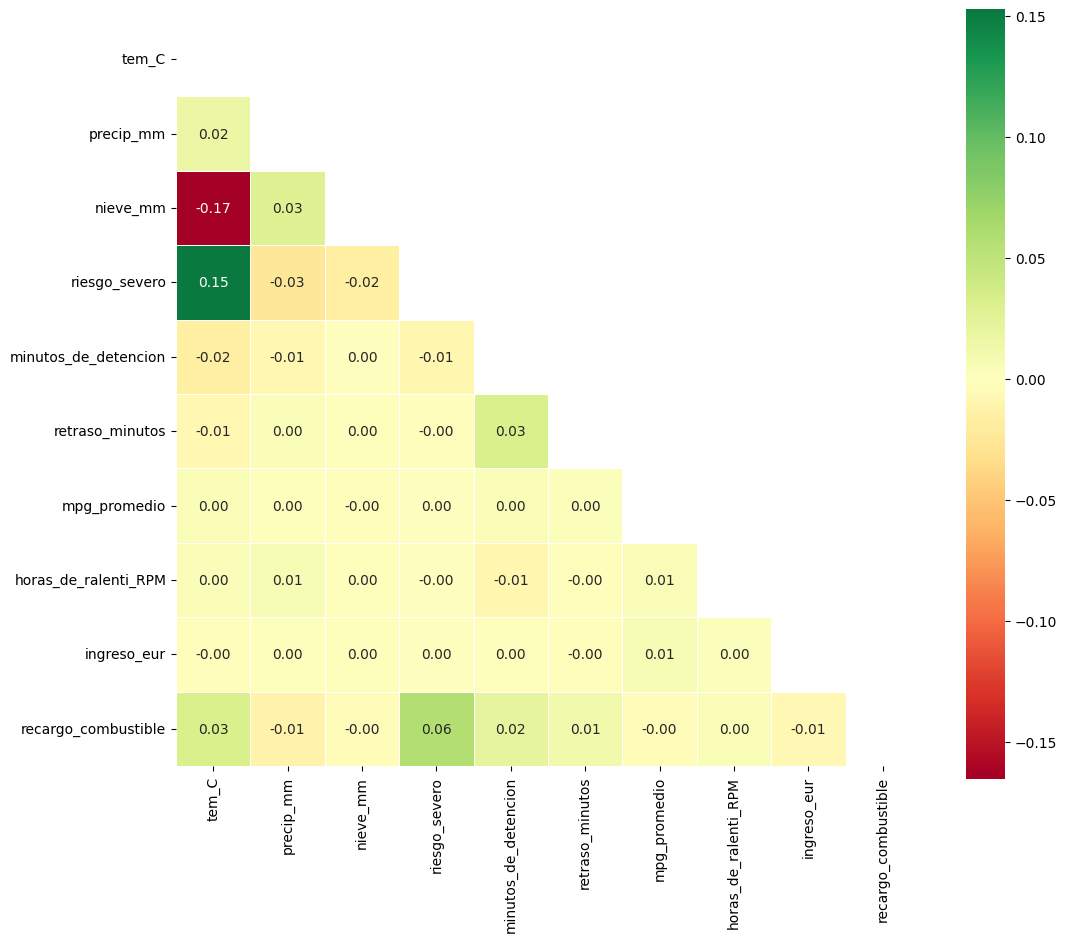

In [137]:
corr = df_trabajo.select_dtypes(include=['number']).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            fmt=".2f",      
            cmap='RdYlGn', 
            center=0,       
            square=True,    
            linewidths=.5)  
plt.show()


La única relación que encontramos es entre los retrasos y los minutos de detención, lo que tiene sentido.

Matriz de Correlación Operativa:
retraso_minutos               1.000000
minutos_de_detencion          0.031201
galones_combustible_usados    0.015405
horas_de_ralenti_RPM         -0.002262
tem_C                        -0.008144
Name: retraso_minutos, dtype: float64


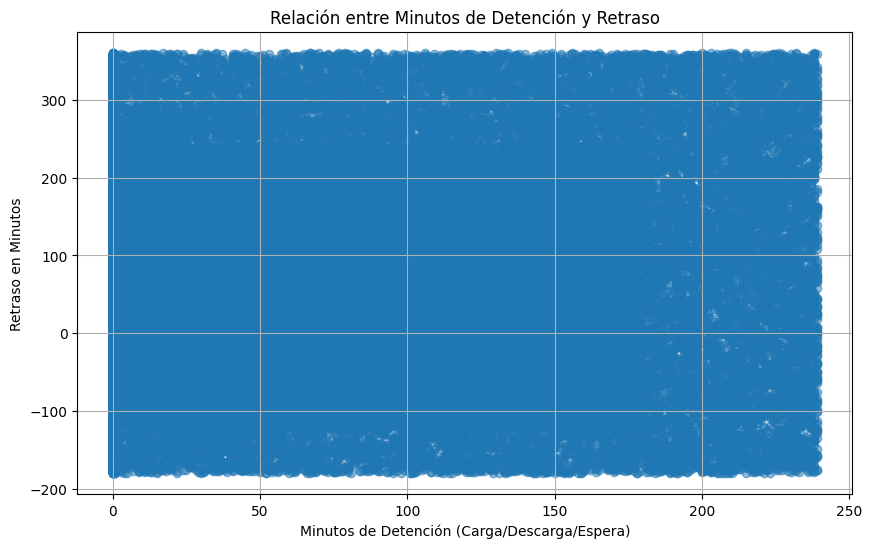

In [138]:
variables_operativas = [
    'retraso_minutos', 
    'minutos_de_detencion', 
    'horas_de_ralenti_RPM', 
    'galones_combustible_usados', "tem_C"
]

correlacion_op = df_union[variables_operativas].corr()

print("Matriz de Correlación Operativa:")
print(correlacion_op['retraso_minutos'].sort_values(ascending=False))


plt.figure(figsize=(10, 6))
plt.scatter(df_union['minutos_de_detencion'], df_union['retraso_minutos'], alpha=0.5)
plt.title('Relación entre Minutos de Detención y Retraso')
plt.xlabel('Minutos de Detención (Carga/Descarga/Espera)')
plt.ylabel('Retraso en Minutos')
plt.grid(True)
plt.show()


## veamos el tipo de datos por carga y la ciudad

In [139]:
grop=df_union[df_union["ciudad"] == "Kansas City"].groupby(["tipo_carga","tipo_carga_principal"])["id_evento"].nunique().reset_index(name='conteo').sort_values(by='conteo', ascending=False)

In [140]:
grop

,tipo_carga,tipo_carga_principal,conteo
7,Seco,Automotriz,1494
1,Refrigerado,Automotriz,1490
6,Seco,Alimentos/Bebidas,1393
0,Refrigerado,Alimentos/Bebidas,1379
5,Refrigerado,Venta por menor,1313
3,Refrigerado,Electrónica,1227
11,Seco,Venta por menor,1215
9,Seco,Electrónica,1191
2,Refrigerado,Bienes de consumo,1091
8,Seco,Bienes de consumo,1058


# Analicemos cada variable por separado

Primero veamos la relación entre precipitaciones y retrasos

In [141]:
coef, p_valor = spearmanr(df_union['precip_mm'], df_union['retraso_minutos'])

print(f"Coeficiente de Correlación de Spearman: {coef:.4f}")
print(f"P-valor: {p_valor:.4f}")

if p_valor < 0.05:
    print("Resultado: Estadísticamente significativo. Hay una relación clara.")
else:
    print("Resultado: No se encontró una relación estadística significativa.")


Coeficiente de Correlación de Spearman: 0.0029
P-valor: 0.4620
Resultado: No se encontró una relación estadística significativa.


# Veamos más retrasos en que ciudades están

In [142]:
analisis_ciudad = df_union.groupby('ciudad')['retraso_minutos'].mean().sort_values(ascending=False)

print("Promedio de retraso por ciudad:")
print(analisis_ciudad)

tarde_por_ciudad = df_union[df_union['retraso_minutos'] > 0]['ciudad'].value_counts()
print("\nCantidad de llegadas tarde por ciudad:")
print(tarde_por_ciudad)


Promedio de retraso por ciudad:
ciudad
Los Angeles    91.659890
New York       79.942255
Portland       76.798696
Detroit        76.748162
Houston        74.040266
Kansas City    72.610054
Miami          69.908720
Name: retraso_minutos, dtype: float64

Cantidad de llegadas tarde por ciudad:
ciudad
Kansas City    9781
Portland       7814
Houston        6884
Los Angeles    5963
Miami          5797
New York       5022
Detroit        2870
Name: count, dtype: int64


# Analizamos el horario más habitual de los retrasos

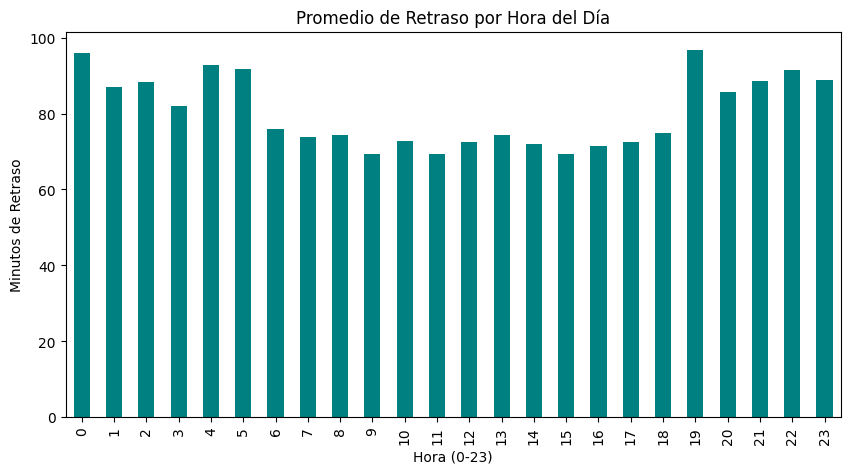

In [143]:

df_union['hora_dia'] = pd.to_datetime(df_union['fecha_hora_programada']).dt.hour

retraso_por_hora = df_union.groupby('hora_dia')['retraso_minutos'].mean()

retraso_por_hora.plot(kind='bar', figsize=(10,5), color='teal')
plt.title('Promedio de Retraso por Hora del Día')
plt.xlabel('Hora (0-23)')
plt.ylabel('Minutos de Retraso')
plt.show()


# Veamos si están mal planificadas las horas de demora

In [144]:

def categorizar_turno(hora):
    if 6 <= hora < 18:
        return 'Día (06:00 - 18:00)'
    else:
        return 'Noche (18:00 - 06:00)'

df_union['turno'] = df_union['hora_dia'].apply(categorizar_turno)

resumen_turnos = df_union.groupby('turno')['retraso_minutos'].agg(['mean', 'count', 'std'])
resumen_turnos.columns = ['Promedio Retraso (min)', 'Total Eventos', 'Desviación Estándar']

print("--- Comparativa de Impacto por Turno ---")
print(resumen_turnos)

tarde_noche = (df_union[(df_union['turno'] == 'Noche (18:00 - 06:00)') & (df_union['retraso_minutos'] > 0)].shape[0] / 
               df_union[df_union['turno'] == 'Noche (18:00 - 06:00)'].shape[0]) * 100

tarde_dia = (df_union[(df_union['turno'] == 'Día (06:00 - 18:00)') & (df_union['retraso_minutos'] > 0)].shape[0] / 
             df_union[df_union['turno'] == 'Día (06:00 - 18:00)'].shape[0]) * 100

print(f"\n% de entregas tarde en la NOCHE: {tarde_noche:.2f}%")
print(f"% de entregas tarde en el DÍA: {tarde_dia:.2f}%")


--- Comparativa de Impacto por Turno ---
                       Promedio Retraso (min)  Total Eventos  \
turno                                                          
Día (06:00 - 18:00)                 72.313505          45760   
Noche (18:00 - 06:00)               87.208665          20386   

                       Desviación Estándar  
turno                                       
Día (06:00 - 18:00)             128.500167  
Noche (18:00 - 06:00)           151.379378  

% de entregas tarde en la NOCHE: 66.70%
% de entregas tarde en el DÍA: 66.73%


comparando ambas distribuciones vemos que son parecidas en el día comparado con la noche

C:\Users\tachi\AppData\Local\Temp\ipykernel_33764\1064342923.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




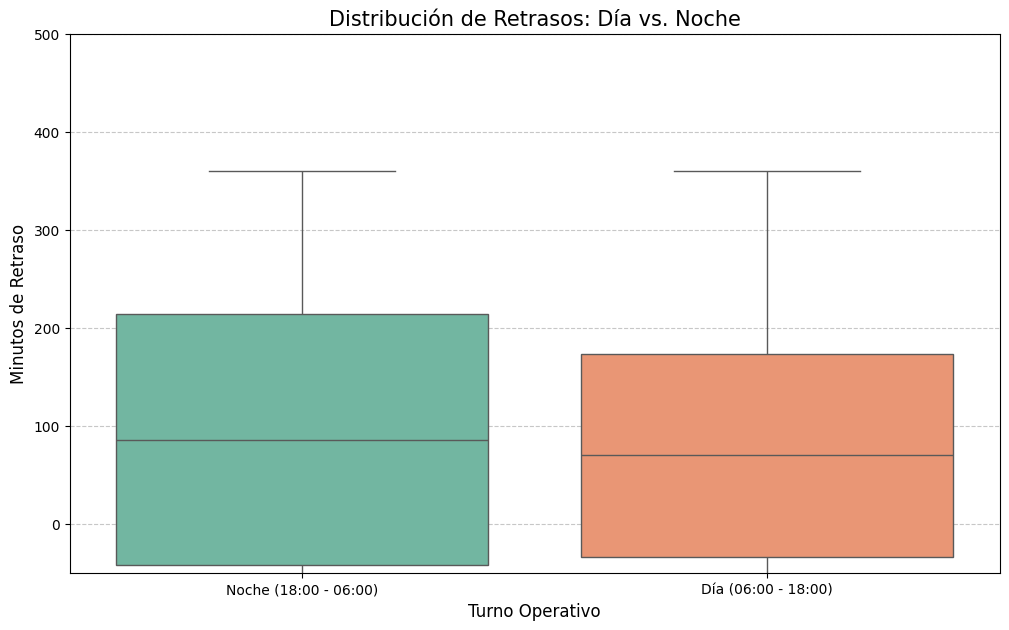

In [145]:
plt.figure(figsize=(12, 7))

sns.boxplot(x='turno', y='retraso_minutos', data=df_union, palette='Set2')

plt.title('Distribución de Retrasos: Día vs. Noche', fontsize=15)
plt.xlabel('Turno Operativo', fontsize=12)
plt.ylabel('Minutos de Retraso', fontsize=12)
plt.ylim(-50, 500) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


Crearemos el data set final para el estudio y llevarlo a hacer el dashboard.

In [146]:
df_union.head()

,id_evento,ciudad,tipo_evento,fecha_hora_programada,fecha_hora_real,retraso_minutos,minutos_de_detencion,tem_max_C,tem_min_C,tem_C,...,tipo_carga,peso_kg,eur_carga,recargo_combustible,cargos_accesorios,tipo_reserva,a_tiempo,categoria_riesgo,hora_dia,turno
0,EVT00000001,Houston,Recogida,2022-01-01 18:00:00,2022-01-01 20:58:55,178.92,0,27,23,25,...,Seco,8699,2591,407,100,Puntual,False,Sin Riesgo,18,Noche (18:00 - 06:00)
1,EVT00000002,Detroit,Entrega,2022-01-02 23:10:56,2022-01-02 21:30:22,-100.57,230,-3,-8,-4,...,Seco,8699,2591,407,100,Puntual,True,Sin Riesgo,23,Noche (18:00 - 06:00)
2,EVT00000003,Kansas City,Recogida,2022-01-01 18:00:00,2022-01-01 17:37:26,-22.57,62,1,-12,-8,...,Seco,12592,1042,99,0,Dedicado,True,Sin Riesgo,18,Noche (18:00 - 06:00)
3,EVT00000006,Portland,Entrega,2022-01-03 04:28:02,2022-01-03 03:05:02,-83.00,11,9,3,5,...,Refrigerado,16145,6102,793,0,Puntual,True,Sin Riesgo,4,Noche (18:00 - 06:00)
4,EVT00000009,Houston,Recogida,2022-01-01 08:00:00,2022-01-01 11:51:35,231.58,73,27,23,25,...,Seco,18260,2822,738,0,Puntual,False,Sin Riesgo,8,Día (06:00 - 18:00)


In [148]:
df_union.to_csv("data_final.csv", index=False)
print("Archivo guardado como data_final.csv")

Archivo guardado como data_final.csv
